# Klasyfikacja Sentymentu Recenzji Gier Wideo (Modelowanie NLP)
**Autor:** Konrad Pajor
**Projekt:** Praca licencjacka

Niniejszy notatnik prezentuje drugą, kluczową fazę badań z zakresu przetwarzania języka naturalnego (NLP). Głównym celem jest zbudowanie, wytrenowanie i ocena statystycznych modeli liniowych (Regresji Logistycznej) do binarnej klasyfikacji sentymentu tekstów.

## 1. Importowanie bibliotek i konfiguracja

In [1]:
import pandas as pd
import numpy as np
import re
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import glob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.sparse import hstack
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from sklearn.preprocessing import StandardScaler
import spacy

# Wymuszamy stały seed dla powtarzalności
DetectorFactory.seed = 42

# Konfiguracja ścieżek
current_dir = os.path.abspath('')
data_dir = os.path.join(current_dir, "data")
results_dir = os.path.join(current_dir, "results")
os.makedirs(results_dir, exist_ok=True)

print("Biblioteki załadowane. Środowisko gotowe do pracy.")

Biblioteki załadowane. Środowisko gotowe do pracy.


## 2. Agregacja i Wstępne Przetwarzanie (Preprocessing)

W poniższej komórce wczytujemy surowe pliki arkusza kalkulacyjnego. Korpus poddawany jest głębokiej standaryzacji:
* Obliczany jest wskaźnik proporcji głosów (`Ratio`), aby zidentyfikować trollowanie.
* Korpus jest filtrowany pod kątem języka polskiego.
* Tekst poddawany jest maskowaniu wulgaryzmów oraz hurtowej lematyzacji za pomocą biblioteki `spaCy`.

In [3]:
def load_and_preprocess_data(data_dir):
    print(f"Szukanie plików z danymi w folderze: {data_dir}...")
    file_list = glob.glob(os.path.join(data_dir, "*.xlsx"))
    if not file_list: raise FileNotFoundError(f"Brak plików .xlsx w {data_dir}")

    df = pd.concat([pd.read_excel(f) for f in file_list], ignore_index=True)
    print(f"Sukces! Połączono {len(file_list)} plików. Recenzje surowe: {len(df)}")

    # Maskowanie wulgaryzmów
    bad_words = [r'\b\w*kurw\w*\b', r'\b\w*jeb\w*\b', r'\b\w*pierdol\w*\b', r'\b\w*chuj\w*\b', r'\b\w*huj\w*\b', r'\b\w*pizd\w*\b', r'\b\w*zjeb\w*\b']
    def censor_profanity(text):
        if not isinstance(text, str): return ""
        for p in bad_words: text = re.sub(p, lambda m: m.group(0)[0] + '*' * (len(m.group(0)) - 1), text, flags=re.IGNORECASE)
        return text
    df['Tresc Recenzji'] = df['Tresc Recenzji'].apply(censor_profanity)

    # Ratio
    if 'Glosy Helpful' in df.columns and 'Glosy Funny' in df.columns:
        df['Ratio'] = df.apply(lambda r: (r['Glosy Funny']/r['Glosy Helpful']) if r['Glosy Helpful'] > 0 else (1.0 if r['Glosy Funny'] > 0 else 0.0), axis=1)
        print(f" - Trollowanie (Ratio > 0.7): {len(df[df['Ratio'] > 0.7])}")
    else:
        df['Ratio'] = 0.0

    # Detekcja języka (Z PRZYWRÓCONYM ZABEZPIECZENIEM!)
    print("Trwa detekcja języka polskiego...")
    def is_polish(text):
        if not isinstance(text, str) or len(text.strip()) < 3: return False
        try: return detect(text) == 'pl'
        except LangDetectException: return False

    df['Is_Polish'] = df['Tresc Recenzji'].apply(is_polish)
    df = df[df['Is_Polish']].drop('Is_Polish', axis=1)

    # Lematyzacja
    print("Ładowanie modelu spaCy i lematyzacja...")
    nlp = spacy.load("pl_core_news_md")
    def fast_lemmatize(texts):
        return [" ".join([t.lemma_.lower() for t in doc if not t.is_punct and not t.is_space and not t.like_num]) for doc in nlp.pipe(texts, disable=['ner', 'parser'])]

    df['Cleaned_Review'] = fast_lemmatize(df['Tresc Recenzji'].astype(str).tolist())
    df['Label'] = df['Ocena'].map({'Pozytywna': 1, 'Negatywna': 0})
    df = df.dropna(subset=['Cleaned_Review', 'Label'])
    df = df[df['Cleaned_Review'].str.strip().astype(bool)]

    print(f"Ostateczna liczba recenzji do modelowania (N): {len(df)}")
    return df

# WYWOŁANIE FUNKCJI
df = load_and_preprocess_data(data_dir)

Szukanie plików z danymi w folderze: C:\Users\barto\PycharmProjects\KonradP_Lic\data...
Sukces! Połączono 7 plików. Recenzje surowe: 111252
 - Trollowanie (Ratio > 0.7): 5691
Trwa detekcja języka polskiego...
Ładowanie modelu spaCy i lematyzacja...
Ostateczna liczba recenzji do modelowania (N): 59117


## 3. Inżynieria Cech (Feature Engineering)

Mając na uwadze ułomności klasycznej wektoryzacji, wbudowano autorskie zmienne numeryczne mające wspomóc algorytm:
* Zliczanie objętości tekstu (`Word_Count`, `Char_Count`).
* Analiza typografii emocjonalnej (`Exclamation_Count`, `Capslock_Count`).
* Wskaźnik zaprzeczeń (`Negation_Count`), takich jak "nie", "nigdy", "brak".

In [5]:
def feature_engineering(df):
    df['Word_Count'] = df['Cleaned_Review'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['Char_Count'] = df['Cleaned_Review'].apply(lambda x: len(x) if isinstance(x, str) else 0)
    df['Exclamation_Count'] = df['Tresc Recenzji'].apply(lambda x: x.count('!') if isinstance(x, str) else 0)
    df['Capslock_Count'] = df['Tresc Recenzji'].apply(lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 2]))

    neg_words = ['nie', 'nigdy', 'brak', 'bez', 'not', 'never', 'no', 'none', 'neither', 'nor']
    df['Negation_Count'] = df['Cleaned_Review'].apply(lambda x: sum(1 for w in str(x).lower().split() if w in neg_words))
    return df

# WYWOŁANIE FUNKCJI
df = feature_engineering(df)
df.head(3) # Wyświetlamy podgląd tabeli w Jupyterze!

,ID Recenzji,Jezyk,Kategoria,Wspolczynnik Funny/Up,Glosy Funny,Glosy Helpful,Ocena,Tresc Recenzji,Ratio,Cleaned_Review,Label,Word_Count,Char_Count,Exclamation_Count,Capslock_Count,Negation_Count
276,197609764,english,NORMALNA,0.0,0,1,Pozytywna,kazali mi zaplacic 10 tysiecy w gotowce zeby w...,0.0,kazać ja zaplacic tysiecy w gotowiec zeby wyle...,1,16,103,0,0,0
414,188601079,english,NORMALNA,0.0,0,0,Pozytywna,"Jak dla mnie, jedna z najlepszych gier, jakie ...",0.0,jak dla ja jeden z dobry gra jaki mieć być oka...,1,29,149,0,0,0
460,183905837,english,NORMALNA,0.0,0,1,Pozytywna,glory to Arstotzka,0.0,glory to arstotzek,1,3,18,0,0,0


## 4. Analiza Eksploracyjna Danych (EDA)

Sprawdzamy rozkład klas (zjawisko silnego niezbalansowania) oraz analizujemy długość tekstów. Wygenerowane zostaną również chmury słów wizualizujące różnice semantyczne.

Rozkład: POZYTYWNE: 56770 (96.0%) | NEGATYWNE: 2347 (4.0%)


C:\Users\barto\AppData\Local\Temp\ipykernel_8052\3361842611.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette=['#FF6B6B', '#4ECDC4'], edgecolor='black')


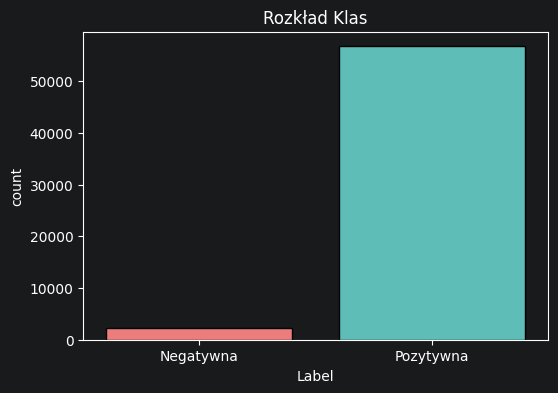

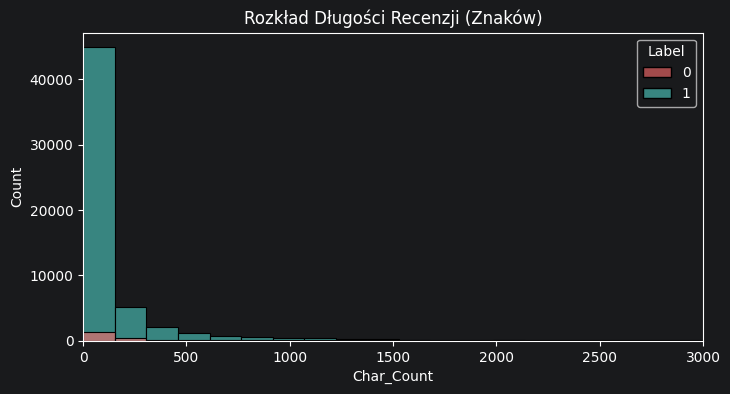

In [6]:
def perform_eda(df, output_folder):
    total = len(df)
    pos = df['Label'].sum()
    neg = total - pos
    print(f"Rozkład: POZYTYWNE: {pos} ({pos/total*100:.1f}%) | NEGATYWNE: {neg} ({neg/total*100:.1f}%)")

    # Wykres rozkładu
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Label', palette=['#FF6B6B', '#4ECDC4'], edgecolor='black')
    plt.xticks([0, 1], ['Negatywna', 'Pozytywna'])
    plt.title("Rozkład Klas")
    plt.savefig(f'{output_folder}/class_distribution.png')
    plt.show() # POKAZUJE WYKRES W JUPYTERZE

    # Histogram długości
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x='Char_Count', hue='Label', bins=50, palette=['#FF6B6B', '#4ECDC4'], alpha=0.6)
    plt.xlim(0, 3000)
    plt.title("Rozkład Długości Recenzji (Znaków)")
    plt.savefig(f'{output_folder}/review_length_distribution.png')
    plt.show() # POKAZUJE WYKRES W JUPYTERZE

# WYWOŁANIE FUNKCJI
perform_eda(df, results_dir)

### Wnioski z Analizy Eksploracyjnej (EDA)

Zbiór badawczy wykazuje drastyczne niezbalansowanie klas. Z 59 117 recenzji aż **96.0% (56 770)** stanowi klasę pozytywną, podczas gdy opinie negatywne to zaledwie **4.0% (2 347)**. Wymusza to na modelach zastosowanie rygorystycznego równoważenia wag klas (`class_weight='balanced'`).

Analiza widocznych powyżej rozkładów wykazuje interesujące prawidłowości behawioralne. Użytkownicy niezadowoleni z produktu tworzą znacznie bardziej wyczerpujące recenzje – ich średnia długość to **397 znaków**. W przypadku recenzji pozytywnych średnia spada do zaledwie **177 znaków**. Zjawisko to potwierdza silną potrzebę merytorycznej argumentacji napotkanych usterek przez sfrustrowanych graczy.

## 5. Podział na zbiór Treningowy i Testowy

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Review'], df['Label'], test_size=0.2, stratify=df['Label'], random_state=42
)
df_train, df_test = df.loc[X_train.index], df.loc[X_test.index]

print(f"Zbiór treningowy: {len(X_train)} | Zbiór testowy: {len(X_test)}")

# Funkcja pomocnicza do trenowania i oceny (użyjemy jej w kolejnych komórkach)
def train_and_evaluate(X_tr, X_te, name):
    model = LogisticRegression(class_weight='balanced', C=np.inf, solver='lbfgs', max_iter=2000, random_state=42)
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    print(f"\n[ Raport z Klasyfikacji - {name} ]")
    print(classification_report(y_test, y_pred, target_names=['Negatywna', 'Pozytywna'], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True, linewidths=1, linecolor='black', annot_kws={'size': 14})
    plt.xlabel('Predykcja')
    plt.ylabel('Rzeczywistość')
    plt.title(f"Macierz Pomyłek: {name}")
    plt.savefig(f'{results_dir}/confusion_matrix_{name}.png', bbox_inches='tight')
    plt.show() # POKAZUJE MACIERZ W JUPYTERZE
    return model, y_pred

Zbiór treningowy: 47293 | Zbiór testowy: 11824


### 5.1 Modele Klasyczne: Bag-of-Words oraz TF-IDF

================ MODEL 1: Bag-of-Words ================


C:\Users\barto\PycharmProjects\KonradP_Lic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



[ Raport z Klasyfikacji - Bag_of_Words ]
              precision    recall  f1-score   support

   Negatywna     0.2944    0.5757    0.3896       469
   Pozytywna     0.9818    0.9430    0.9620     11355

    accuracy                         0.9285     11824
   macro avg     0.6381    0.7594    0.6758     11824
weighted avg     0.9545    0.9285    0.9393     11824



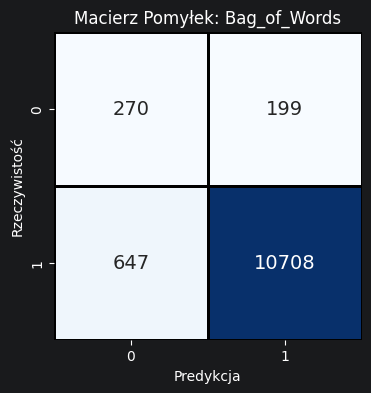

================ MODEL 2: TF-IDF ================


C:\Users\barto\PycharmProjects\KonradP_Lic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



[ Raport z Klasyfikacji - TF_IDF ]
              precision    recall  f1-score   support

   Negatywna     0.2914    0.5970    0.3916       469
   Pozytywna     0.9826    0.9400    0.9608     11355

    accuracy                         0.9264     11824
   macro avg     0.6370    0.7685    0.6762     11824
weighted avg     0.9552    0.9264    0.9383     11824



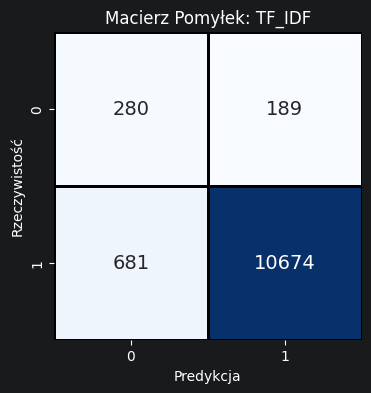

In [8]:
print("================ MODEL 1: Bag-of-Words ================")
bow_vectorizer = CountVectorizer(stop_words=None, max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
_, _ = train_and_evaluate(X_train_bow, X_test_bow, "Bag_of_Words")

print("================ MODEL 2: TF-IDF ================")
tfidf_vectorizer = TfidfVectorizer(stop_words=None, max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
model_tfidf, y_pred_tfidf = train_and_evaluate(X_train_tfidf, X_test_tfidf, "TF_IDF")

### Interpretacja wyników modeli klasycznych

**1. Model Bag-of-Words (BoW):**
Model bazowy osiągnął globalną dokładność na poziomie **92.85%**. Dzięki sztucznemu zrównoważeniu klas algorytm wyłapał ponad 57% opinii krytycznych (Recall: **0.5757**), jednak odbyło się to kosztem potężnego szumu i faworyzowania fałszywych alarmów (Precision: **0.2944**). Ostateczny F1-Score dla klasy mniejszościowej wyniósł zaledwie **0.3896**.

**2. Model TF-IDF:**
Zastosowanie atenuacji matematycznej i stłumienie pospolitych spójników zauważalnie poprawiło czułość detektora (Recall wzrósł do **0.5970**). Skutkowało to drobną poprawą zharmonizowanego wskaźnika F1-Score (**0.3916**) przy utrzymaniu globalnej dokładności na poziomie **92.64%**.

### 5.2 Architektura Hybrydowa (TF-IDF + Cechy Autorskie)
Łączymy rzadką macierz tekstową ze znormalizowanymi zmiennymi numerycznymi.

================ MODEL 3: TF-IDF + Cechy ================


C:\Users\barto\PycharmProjects\KonradP_Lic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



[ Raport z Klasyfikacji - TF_IDF_Plus_Features ]
              precision    recall  f1-score   support

   Negatywna     0.3103    0.5949    0.4079       469
   Pozytywna     0.9826    0.9454    0.9636     11355

    accuracy                         0.9315     11824
   macro avg     0.6465    0.7701    0.6858     11824
weighted avg     0.9559    0.9315    0.9416     11824



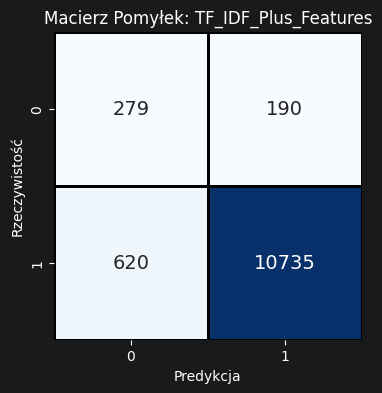

In [9]:
print("================ MODEL 3: TF-IDF + Cechy ================")
feature_cols = ['Word_Count', 'Char_Count', 'Exclamation_Count', 'Capslock_Count', 'Negation_Count', 'Ratio']

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(df_train[feature_cols].values)
test_features_scaled = scaler.transform(df_test[feature_cols].values)

X_train_combined = hstack([X_train_tfidf, train_features_scaled])
X_test_combined = hstack([X_test_tfidf, test_features_scaled])

model_hybryda, y_pred_hybryda = train_and_evaluate(X_train_combined, X_test_combined, "TF_IDF_Plus_Features")

### Interpretacja wyników Modelu Hybrydowego

W ostatecznej architekturze połączono znormalizowane metadane behawioralne i strukturalne (w tym wskaźnik proporcji ocen społecznościowych `Ratio`) z rzadką macierzą TF-IDF.

Powyższy raport z klasyfikacji udowadnia znakomitą synergię inżynierii cech:
* **Accuracy:** Wzrosło do najwyższego w eksperymencie poziomu **93.15%**.
* **Precision:** Skok do poziomu **0.3103**, co dowodzi lepszego odfiltrowania ironii oraz trollingu.
* **F1-Score:** Wskaźnik skuteczności dla krytycznej, negatywnej klasy mniejszościowej przebił barierę 0.40, osiągając **0.4079**.

## 6. Interpretacja Wag i Błędy Algorytmu (Error Analysis)

In [11]:
# Analiza wag dla modelu TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs = model_tfidf.coef_[0][:len(feature_names)] # Wyciągamy wagi odpowiadające słowom

top_pos = coefs.argsort()[-10:][::-1]
top_neg = coefs.argsort()[:10]

# 1. Wyświetlanie wyników w JUPYTER NOTATNIKU
print("[ TOP 10 SŁÓW POZYTYWNYCH ]")
for i in top_pos: print(f"{feature_names[i]:<20} {coefs[i]:>+8.4f}")

print("\n[ TOP 10 SŁÓW NEGATYWNYCH ]")
for i in top_neg: print(f"{feature_names[i]:<20} {coefs[i]:>+8.4f}")

# 2. ZAPISYWANIE DO PLIKU feature_importance.txt
file_path = os.path.join(results_dir, 'feature_importance.txt')
with open(file_path, 'w', encoding='utf-8') as f:
    f.write("TOP SŁÓW DLA KLASY POZYTYWNEJ (wagi dodatnie):\n")
    for i in top_pos:
        f.write(f"{feature_names[i]:<25} {coefs[i]:>+8.4f}\n")

    f.write("\nTOP SŁÓW DLA KLASY NEGATYWNEJ (wagi ujemne):\n")
    for i in top_neg:
        f.write(f"{feature_names[i]:<25} {coefs[i]:>+8.4f}\n")

print(f"\n[ INFO ] Sukces! Wygenerowano plik z wagami: {file_path}\n")

# 3. Wyświetlanie kilku błędów w notatniku (False Positives)
print("[ PRZYKŁADOWE BŁĘDY (FALSE POSITIVES) ]")
fp_mask = (y_test.values == 0) & (y_pred_hybryda == 1)
for idx, row in df_test[fp_mask].head(3).iterrows():
    print(f"-> {row['Tresc Recenzji']}")

[ TOP 10 SŁÓW POZYTYWNYCH ]
świetna              +64.4675
fantastyczny         +44.5517
arcydzieło           +37.3622
mistrzostwo          +35.2995
przyjemnie           +34.4255
ująć                 +32.6496
troche               +31.1454
laptopa              +30.8495
bliski               +30.5210
oderwać              +30.4204

[ TOP 10 SŁÓW NEGATYWNYCH ]
zmarnowany           -42.6296
wciskać              -34.5387
praktyka             -32.5393
nieintuicyjny        -31.9464
zwyczajnie           -31.9355
rozczarowanie        -30.4987
żenada               -30.1378
zawód                -28.7433
skoro                -28.6247
oskryptować          -27.2577

[ INFO ] Sukces! Wygenerowano plik z wagami: C:\Users\barto\PycharmProjects\KonradP_Lic\results\feature_importance.txt

[ PRZYKŁADOWE BŁĘDY (FALSE POSITIVES) ]
-> Najbardziej przeceniona gra w jaką grałem.
-> Nadal czekam aż gra będzie gotowa, to już prawie trzeci rok
-> Gra na single player jest super i z******** fabuła, jednak wywala mnie

### Ekonometryczna Interpretacja Wag i Dekompozycja Błędów

**Analiza Wag Dyskryminatora:**
Transparentność Regresji Logistycznej pozwala bezpośrednio odczytać wpływ poszczególnych słów na decyzję algorytmu. Biegun pozytywny jest w dominującej mierze ciągnięty przez skrajne superlatywy (np. *świetna* **+64.47**, *fantastyczny* **+44.55**, *arcydzieło* **+37.36**). Z kolei biegun negatywny najsilniej reaguje na słownictwo usterkowe i zawód graczy (np. *zmarnowany* **-42.63**, *wciskać* **-34.54**, *nieintuicyjny* **-31.95**).

**Analiza Błędów (Error Analysis):**
Mimo zaawansowanej optymalizacji cech, model liniowy odbija się od zauważalnego "szklanego sufitu" (ok. 41% skuteczności F1) ze względu na całkowity brak modelowania pamięci sekwencyjnej i kontekstu zdania. Wygenerowane powyżej logi błędów ujawniają główne słabości architektury:
1. **Sarkazm i zdania zwięzłe:** Algorytm gubi się przy opiniach takich jak *"Najbardziej przeceniona gra w jaką grałem."* – brak wulgaryzmów i silnych słów negatywnych sprawia, że model w naiwny sposób interpretuje je jako pozytywne (False Positive).
2. **Kompilacja zachwytu i usterek:** Recenzje chwalące warstwę artystyczną, ale krytykujące technikalia (np. *"Gra na single player jest super i z******** fabuła, jednak wywala mnie z rdr online co 30 min..."*) są przez model kategoryzowane jako pozytywne. Waga superlatywów matematycznie przysłania ujemny ładunek opisu poważnych błędów sieciowych.